# DS -Week 8
Analyzing the Epidemiological Outbreak of COVID-19: A Visual Exploratory Data Analysis (EDA) Approach

Overall Idea: Predict numbers of infections, create graphics,
analyze spreading over time.
* Citation(s) that contain more details:
https://www.ncbi.nlm.nih.gov/pubmed/32124990
* In this project, the same analysis and visualization should be done
(http://samratdey.me/visualization.html), but instead of China
and ist provinces, Germany and its states (optional: Landkreise)
should be used.
* Time-series analysis should be performed in some way. This could
be change-point detection, or trend analysis with some “alert”
function that give notification of changing trends (e.g. from: R<1
to R>1 over some time), or some prediction of the individual timeseries, or some clustering of the time-series

# Environment preparation

In [1]:
! pip install -q kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets download -d  'headsortails/covid19-tracking-germany'
!unzip \*.zip

  0% 0.00/3.02M [00:00<?, ?B/s]
100% 3.02M/3.02M [00:00<00:00, 97.0MB/s]
Archive:  covid19-tracking-germany.zip
  inflating: covid_de.csv            
  inflating: de_county.cpg           
  inflating: de_county.dbf           
  inflating: de_county.prj           
  inflating: de_county.shp           
  inflating: de_county.shx           
  inflating: de_state.cpg            
  inflating: de_state.dbf            
  inflating: de_state.prj            
  inflating: de_state.shp            
  inflating: de_state.shx            
  inflating: demographics_de.csv     


In [2]:
!pip install geopandas
!pip install plotly==4.5.2
!pip install wget

     |████████████████████████████████| 931kB 8.2MB/s 
     |████████████████████████████████| 10.9MB 29.7MB/s 
     |████████████████████████████████| 14.7MB 302kB/s 
     |████████████████████████████████| 7.1MB 8.1MB/s 
  Found existing installation: plotly 4.4.1
    Uninstalling plotly-4.4.1:
      Successfully uninstalled plotly-4.4.1
  Created wheel for wget: filename=wget-3.2-cp36-none-any.whl size=9682 sha256=2323e0eaf45ca294f024e9587cbed809475442933c0c4fbd8d9559e194046732
  Stored in directory: /root/.cache/pip/wheels/40/15/30/7d8f7cea2902b4db79e3fea550d7d7b85ecb27ef992b618f3f
Successfully built wget


In [3]:
# to download data
import wget
urls = [  "https://raw.githubusercontent.com/imdevskp/covid_19_jhu_data_web_scrap_and_cleaning/master/covid_19_clean_complete.csv"]

for url in urls:
    filename = wget.download(url)

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates

sns.set(style="white", color_codes=True)
import warnings # current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta


import geopandas as gpd

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [5]:
# interactive visualization
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
# import plotly.figure_factory as ff
from plotly.subplots import make_subplots

In [6]:
who_region = {}
# African Region AFRO
afro = "Algeria, Angola, Cabo Verde, Eswatini, Sao Tome and Principe, Benin, South Sudan, Western Sahara, Congo (Brazzaville), Congo (Kinshasa), Cote d'Ivoire, Botswana, Burkina Faso, Burundi, Cameroon, Cape Verde, Central African Republic, Chad, Comoros, Ivory Coast, Democratic Republic of the Congo, Equatorial Guinea, Eritrea, Ethiopia, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Kenya, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mauritius, Mozambique, Namibia, Niger, Nigeria, Republic of the Congo, Rwanda, São Tomé and Príncipe, Senegal, Seychelles, Sierra Leone, Somalia, South Africa, Swaziland, Togo, Uganda, Tanzania, Zambia, Zimbabwe"
afro = [i.strip() for i in afro.split(',')]
for i in afro:
    who_region[i] = 'Africa'
    
# Region of the Americas PAHO
paho = 'Antigua and Barbuda, Argentina, Bahamas, Barbados, Belize, Bolivia, Brazil, Canada, Chile, Colombia, Costa Rica, Cuba, Dominica, Dominican Republic, Ecuador, El Salvador, Grenada, Guatemala, Guyana, Haiti, Honduras, Jamaica, Mexico, Nicaragua, Panama, Paraguay, Peru, Saint Kitts and Nevis, Saint Lucia, Saint Vincent and the Grenadines, Suriname, Trinidad and Tobago, United States, US, Uruguay, Venezuela'
paho = [i.strip() for i in paho.split(',')]
for i in paho:
    who_region[i] = 'Americas'

# South-East Asia Region SEARO
searo = 'Bangladesh, Bhutan, North Korea, India, Indonesia, Maldives, Myanmar, Burma, Nepal, Sri Lanka, Thailand, Timor-Leste'
searo = [i.strip() for i in searo.split(',')]
for i in searo:
    who_region[i] = 'South-East Asia'

# European Region EURO
euro = 'Albania, Andorra, Greenland, Kosovo, Holy See, Liechtenstein, Armenia, Czechia, Austria, Azerbaijan, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Croatia, Cyprus, Czech Republic, Denmark, Estonia, Finland, France, Georgia, Germany, Greece, Hungary, Iceland, Ireland, Israel, Italy, Kazakhstan, Kyrgyzstan, Latvia, Lithuania, Luxembourg, Malta, Monaco, Montenegro, Netherlands, North Macedonia, Norway, Poland, Portugal, Moldova, Romania, Russia, San Marino, Serbia, Slovakia, Slovenia, Spain, Sweden, Switzerland, Tajikistan, Turkey, Turkmenistan, Ukraine, United Kingdom, Uzbekistan'
euro = [i.strip() for i in euro.split(',')]
for i in euro:
    who_region[i] = 'Europe'

# Eastern Mediterranean Region EMRO
emro = 'Afghanistan, Bahrain, Djibouti, Egypt, Iran, Iraq, Jordan, Kuwait, Lebanon, Libya, Morocco, Oman, Pakistan, Palestine, West Bank and Gaza, Qatar, Saudi Arabia, Somalia, Sudan, Syria, Tunisia, United Arab Emirates, Yemen'
emro = [i.strip() for i in emro.split(',')]
for i in emro:
    who_region[i] = 'Eastern Mediterranean'

# Western Pacific Region WPRO
wpro = 'Australia, Brunei, Cambodia, China, Cook Islands, Fiji, Japan, Kiribati, Laos, Malaysia, Marshall Islands, Micronesia, Mongolia, Nauru, New Zealand, Niue, Palau, Papua New Guinea, Philippines, South Korea, Samoa, Singapore, Solomon Islands, Taiwan, Taiwan*, Tonga, Tuvalu, Vanuatu, Vietnam'
wpro = [i.strip() for i in wpro.split(',')]
for i in wpro:
    who_region[i] = 'Western Pacific'

Import data

In [7]:
full_table = pd.read_csv('covid_19_clean_complete.csv')
full_table.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.0000,65.0000,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.1533,20.1683,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.0339,1.6596,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.5063,1.5218,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.2027,17.8739,2020-01-22,0,0,0,0,Africa


## Full Grouped

In [8]:

# Grouped by day, country
# =======================

full_grouped = full_table.groupby(['Date', 'Country/Region'])['Confirmed', 'Deaths', 'Recovered', 'Active'].sum().reset_index()

# new cases ======================================================
temp = full_grouped.groupby(['Country/Region', 'Date', ])['Confirmed', 'Deaths', 'Recovered']
temp = temp.sum().diff().reset_index()

mask = temp['Country/Region'] != temp['Country/Region'].shift(1)

temp.loc[mask, 'Confirmed'] = np.nan
temp.loc[mask, 'Deaths'] = np.nan
temp.loc[mask, 'Recovered'] = np.nan

# renaming columns
temp.columns = ['Country/Region', 'Date', 'New cases', 'New deaths', 'New recovered']
# =================================================================

# merging new values
full_grouped = pd.merge(full_grouped, temp, on=['Country/Region', 'Date'])

# filling na with 0
full_grouped = full_grouped.fillna(0)

# fixing data types
cols = ['New cases', 'New deaths', 'New recovered']
full_grouped[cols] = full_grouped[cols].astype('int')

full_grouped['New cases'] = full_grouped['New cases'].apply(lambda x: 0 if x<0 else x)
full_grouped[cols] = full_grouped[cols].abs()
full_grouped

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0
1,2020-01-22,Albania,0,0,0,0,0,0,0
2,2020-01-22,Algeria,0,0,0,0,0,0,0
3,2020-01-22,Andorra,0,0,0,0,0,0,0
4,2020-01-22,Angola,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
28419,2020-06-21,West Bank and Gaza,833,3,439,391,49,0,2
28420,2020-06-21,Western Sahara,9,1,8,0,0,0,0
28421,2020-06-21,Yemen,941,256,347,338,19,2,19
28422,2020-06-21,Zambia,1430,11,1194,225,0,0,0


## Day wise

In [9]:
full_grouped[full_grouped['Confirmed']!=0] \
                                    .groupby('Date')['Country/Region'] \
                                    .unique() \
                                    .apply(len)\
                                    .values

array([  6,   8,   9,  11,  13,  16,  16,  18,  20,  24,  25,  25,  25,
        26,  26,  26,  26,  26,  26,  26,  26,  26,  26,  27,  27,  27,
        27,  27,  28,  28,  30,  30,  30,  35,  40,  46,  50,  56,  60,
        65,  72,  76,  80,  84,  93,  94,  99, 102, 105, 111, 113, 120,
       133, 137, 143, 146, 150, 154, 161, 163, 168, 169, 171, 174, 175,
       176, 176, 176, 177, 179, 179, 180, 180, 180, 182, 183, 183, 183,
       183, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184,
       184, 184, 184, 184, 184, 184, 184, 184, 186, 186, 186, 186, 186,
       186, 186, 186, 186, 186, 186, 186, 186, 187, 187, 187, 187, 187,
       187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187,
       187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187, 187,
       187, 187, 187, 187, 187, 187, 187, 187, 187])

In [10]:
# Day wise
# ========

# table
day_wise = full_grouped.groupby('Date')['Confirmed', 'Deaths', 'Recovered', 
                                        'Active', 'New cases', 'New deaths', 'New recovered'].sum().reset_index()

# number cases per 100 cases
day_wise['Deaths / 100 Cases'] = round((day_wise['Deaths']/day_wise['Confirmed'])*100, 2)
day_wise['Recovered / 100 Cases'] = round((day_wise['Recovered']/day_wise['Confirmed'])*100, 2)
day_wise['Deaths / 100 Recovered'] = round((day_wise['Deaths']/day_wise['Recovered'])*100, 2)

# no. of countries
day_wise['No. of countries'] = full_grouped[full_grouped['Confirmed']!=0] \
                                    .groupby('Date')['Country/Region'] \
                                    .unique() \
                                    .apply(len)\
                                    .values

# fillna by 0
cols = ['Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered']
day_wise[cols] = day_wise[cols].fillna(0)

day_wise.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


## Country wise latest

In [11]:
# ============

full_grouped['Date'] = pd.to_datetime(full_grouped['Date'])

# getting latest values
country_wise = full_grouped[full_grouped['Date']==max(full_grouped['Date'])] \
                    .reset_index(drop=True) \
                    .drop('Date', axis=1)

print(country_wise.shape)

# group by country
country_wise = country_wise.groupby('Country/Region')['Confirmed', 'Deaths', 
                                                      'Recovered', 'Active', 
                                                      'New cases', 'New deaths', 'New recovered'].sum().reset_index()
print(country_wise.shape)


# per 100 cases
country_wise['Deaths / 100 Cases'] = round((country_wise['Deaths']/country_wise['Confirmed'])*100, 2)
country_wise['Recovered / 100 Cases'] = round((country_wise['Recovered']/country_wise['Confirmed'])*100, 2)
country_wise['Deaths / 100 Recovered'] = round((country_wise['Deaths']/country_wise['Recovered'])*100, 2)

cols = ['Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered']
country_wise[cols] = country_wise[cols].fillna(0)


# 1 week increase and % change
# ============================

today = full_grouped[full_grouped['Date']==max(full_grouped['Date'])] \
            .reset_index(drop=True) \
            .drop('Date', axis=1)[['Country/Region', 'Confirmed']]

last_week = full_grouped[full_grouped['Date']==max(full_grouped['Date'])-timedelta(days=7)] \
                .reset_index(drop=True) \
                .drop('Date', axis=1)[['Country/Region', 'Confirmed']]

temp = pd.merge(today, last_week, on='Country/Region', suffixes=(' today', ' last week'))
temp['1 week change'] = temp['Confirmed today'] - temp['Confirmed last week']
temp = temp[['Country/Region', 'Confirmed last week', '1 week change']]

country_wise = pd.merge(country_wise, temp, on='Country/Region')
country_wise['1 week % increase'] = round(country_wise['1 week change']/country_wise['Confirmed last week']*100, 2)
country_wise.head()

country_wise['WHO Region'] = country_wise['Country/Region'].map(who_region)
country_wise[country_wise['WHO Region'].isna()]['Country/Region'].unique()

country_wise.head()

(187, 8)
(187, 8)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,28833,581,8764,19488,409,12,472,2.02,30.40,6.63,24766,4067,16.42,Eastern Mediterranean
1,Albania,1962,44,1134,784,71,1,8,2.24,57.80,3.88,1521,441,28.99,Europe
2,Algeria,11771,845,8422,2504,140,8,98,7.18,71.55,10.03,10919,852,7.80,Africa
3,Andorra,855,52,792,11,0,0,0,6.08,92.63,6.57,853,2,0.23,Europe
4,Angola,183,9,77,97,7,0,11,4.92,42.08,11.69,140,43,30.71,Africa


## Function 

In [12]:
def plot_treemap(col, country_list = None):
    if country_list is None:
      fig = px.treemap(country_wise, path=["Country/Region"], values=col, height=700,
                  title=col, color_discrete_sequence = px.colors.qualitative.Dark2)
    else:
      fig = px.treemap(country_wise[country_wise["Country/Region"].isin(country_list)], path=["Country/Region"], values=col, height=700,
                  title=col, color_discrete_sequence = px.colors.qualitative.Dark2)
    fig.data[0].textinfo = 'label+text+value'
    fig.show()

def plot_stacked(col, country_list = None ,title = None ):
    if title is None:
      title = col 

    if country_list is None:
      fig = px.bar(full_grouped, x="Date", y=col, color='Country/Region', 
                  height=600, title=title, 
                  color_discrete_sequence = px.colors.cyclical.mygbm)
    else:
      fig = px.bar(full_grouped[full_grouped["Country/Region"].isin(country_list)], x="Date", y=col, color='Country/Region', 
                  height=600, title=title, 
                  color_discrete_sequence = px.colors.cyclical.mygbm)
    fig.update_layout(showlegend=True)
    fig.show()

def plot_sup_stacked(country_list = ["Germany"]):
    fig, axs = plt.subplots(1, 3)
    axs[0, 0].bar(full_grouped[full_grouped["Country/Region"].isin(country_list)])
    axs[0, 0].set_title("Confirmed")
    axs[0, 1].bar(full_grouped[full_grouped["Country/Region"].isin(country_list)] )
    axs[0, 1].set_title("Death")
    axs[1, 1].bar(full_grouped[full_grouped["Country/Region"].isin(country_list)])
    axs[1, 1].set_title("Recovered")
    fig.tight_layout()
    fig.show()    

In [13]:
def plot_daywise_line(col, hue, country_list = None):
    if country_list is None:
      fig = px.line(day_wise, x="Date", y=col, width=700, color_discrete_sequence=[hue])
    else:
      fig = px.line(day_wise[day_wise["Country/Region"].isin(country_list)], x="Date", y=col, width=700, color_discrete_sequence=[hue])  
    fig.update_layout(title=col, xaxis_title="", yaxis_title="")
    fig.show()

def plot_daywise(col, hue, country_list = None):
    if country_list is None:
      fig = px.bar(day_wise, x="Date", y=col, width=700, color_discrete_sequence=[hue])
    else:
      fig = px.bar(day_wise[day_wise["Country/Region"].isin(country_list)], x="Date", y=col, width=700, color_discrete_sequence=[hue])
    fig.update_layout(title=col, xaxis_title="", yaxis_title="")
    fig.show()
  

In [14]:
norm_axis1 = 18e3
norm_axis2 = 2600

def add_case_per_state(state):
    case = covid_de.loc[covid_de['state'] == state ].cases.sum()
    #print(case)
    shape_de[shape_de.state == state].plot(figsize=(10,10), color= cm.Blues(case/norm_axis1), edgecolor='gainsboro', zorder=3, ax =  ax1)


def add_death_per_state(state):
    death = _df_germany_state_cumulative.loc[_df_germany_state_cumulative['state'] == state ].cumsum_deaths.sum()
    #print(death)
    shape_de[shape_de.state == state].plot(figsize=(10,10), color= cm.YlOrRd(death/norm_axis2), edgecolor='gainsboro', zorder=3, ax = ax2)

# World dataset

##  MAP View of Coutries with Confirmed and Death reported

In [15]:
def plot_map(df, col, pal):
    df = df[df[col]>0]
    fig = px.choropleth(df, locations="Country/Region", locationmode='country names', 
                  color=col, hover_name="Country/Region", 
                  title=col, hover_data=[col], color_continuous_scale=pal)
#     fig.update_layout(coloraxis_showscale=False)
    fig.show()

In [16]:
plot_map(country_wise, 'Confirmed', 'matter')

In [17]:
plot_map(country_wise, 'Deaths', 'matter')

In [18]:
# over the time 
fig = px.choropleth(full_grouped, locations="Country/Region", 
                    color=np.log(full_grouped["Confirmed"]),
                    locationmode='country names', hover_name="Country/Region", 
                    animation_frame=full_grouped["Date"].dt.strftime('%Y-%m-%d'),
                    title='Cases over time', color_continuous_scale=px.colors.sequential.matter)
fig.update(layout_coloraxis_showscale=False)
fig.show()

## VEDA of COVID-19 Spread over time 

In [19]:
'''
py.init_notebook_mode(connected=True)
formated_gdf = full_table.groupby(['Date', 'Country/Region'])['Confirmed', 'Deaths', 'Recovered'].max()
formated_gdf = formated_gdf.reset_index()
formated_gdf['Date'] = pd.to_datetime(formated_gdf['Date'])
formated_gdf['Date'] = formated_gdf['Date'].dt.strftime('%m/%d/%Y')
formated_gdf['size'] = formated_gdf['Confirmed'].pow(0.3)

fig = px.scatter_geo(formated_gdf, locations="Country/Region", locationmode='country names', 
                     color="Confirmed", size='size', hover_name="Country/Region", 
                     range_color= [0, max(formated_gdf['Confirmed'])+2], 
                     projection="natural earth", animation_frame="Date", 
                     title='Progression of spread of COVID-19')
fig.update(layout_coloraxis_showscale=False)
py.offline.iplot(fig)
'''

'\npy.init_notebook_mode(connected=True)\nformated_gdf = full_table.groupby([\'Date\', \'Country/Region\'])[\'Confirmed\', \'Deaths\', \'Recovered\'].max()\nformated_gdf = formated_gdf.reset_index()\nformated_gdf[\'Date\'] = pd.to_datetime(formated_gdf[\'Date\'])\nformated_gdf[\'Date\'] = formated_gdf[\'Date\'].dt.strftime(\'%m/%d/%Y\')\nformated_gdf[\'size\'] = formated_gdf[\'Confirmed\'].pow(0.3)\n\nfig = px.scatter_geo(formated_gdf, locations="Country/Region", locationmode=\'country names\', \n                     color="Confirmed", size=\'size\', hover_name="Country/Region", \n                     range_color= [0, max(formated_gdf[\'Confirmed\'])+2], \n                     projection="natural earth", animation_frame="Date", \n                     title=\'Progression of spread of COVID-19\')\nfig.update(layout_coloraxis_showscale=False)\npy.offline.iplot(fig)\n'

In [20]:
#df_countries.loc[df_countries["Country/Region"] == "Thailand"]

In [21]:
## Number of Confirmed, Deaths and Recovered Cases in Thaialnd

## Time-series analysis

## Prophet

##  LSTM

# Germany dataset

In [22]:
#getting the data
covid_confirmed_de_state  = pd.read_csv("confirmed_de_state.csv", index_col="State") #cases
covid_dead_de_state  = pd.read_csv("death_de_state.csv", index_col="State") #dead
covid_recover_de_state  = pd.read_csv("recover_de_state.csv", index_col="State") #recover

In [23]:
covid_confirmed_de_state

,2020/1/28,2020/1/29,2020/1/31,2020/2/3,2020/2/4,2020/2/6,2020/2/7,2020/2/11,2020/2/12,2020/2/20,2020/2/22,2020/2/24,2020/2/25,2020/2/26,2020/2/27,2020/2/28,2020/2/29,2020/3/1,2020/3/2,2020/3/3,2020/3/4,2020/3/5,2020/3/6,2020/3/7,2020/3/8,2020/3/9,2020/3/10,2020/3/11,2020/3/12,2020/3/13,2020/3/14,2020/3/15,2020/3/16,2020/3/17,2020/3/18,2020/3/19,2020/3/20,2020/3/21,2020/3/22,2020/3/23,...,2020/5/2,2020/5/3,2020/5/4,2020/5/5,2020/5/6,2020/5/7,2020/5/8,2020/5/9,2020/5/10,2020/5/11,2020/5/12,2020/5/13,2020/5/14,2020/5/15,2020/5/16,2020/5/17,2020/5/18,2020/5/19,2020/5/20,2020/5/21,2020/5/22,2020/5/23,2020/5/24,2020/5/25,2020/5/26,2020/5/27,2020/5/28,2020/5/29,2020/5/30,2020/5/31,2020/6/1,2020/6/2,2020/6/3,2020/6/4,2020/6/5,2020/6/6,2020/6/7,2020/6/8,2020/6/9,2020/6/10
State,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Baden-Wuerttemberg,0,0,0,0,0,0,0,1,0,1,0,1,3,4,3,6,2,1,10,23,37,36,51,31,19,52,117,147,188,314,326,182,428,599,801,654,845,562,546,644,...,112,49,78,124,127,182,205,127,52,97,101,123,102,104,53,31,41,101,84,42,63,49,17,32,57,79,60,36,24,11,7,14,29,45,34,30,13,10,23,12
Bayern,2,2,3,1,3,1,1,2,1,0,0,0,0,0,1,2,2,4,6,6,10,19,49,18,21,78,111,116,131,250,232,166,267,460,740,818,859,1108,558,719,...,136,90,165,213,264,233,210,122,78,189,211,190,207,133,101,57,88,109,193,93,117,78,94,88,132,114,88,80,83,41,20,36,55,84,59,23,37,32,43,58
Berlin,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,3,9,5,1,11,22,34,42,47,59,29,26,63,93,146,179,170,128,68,159,...,31,32,52,53,58,58,4,17,8,16,37,58,44,16,16,8,33,46,48,9,36,7,3,22,22,41,25,30,23,27,2,41,55,32,30,15,8,30,53,35
Brandenburg,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,4,4,9,8,25,21,15,21,24,68,56,58,66,25,22,54,...,16,6,19,44,26,12,17,5,2,9,6,10,16,6,20,1,6,5,16,3,5,4,0,10,4,8,9,7,5,1,0,8,7,5,6,1,0,4,6,18
Bremen,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,0,0,0,0,0,7,11,11,7,9,3,3,1,12,10,40,24,22,4,12,...,4,17,17,10,54,29,28,15,12,3,20,29,23,21,19,10,11,19,18,16,4,3,13,2,10,26,26,29,24,7,1,11,17,34,15,5,14,1,15,17
Hamburg,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,0,3,3,5,3,4,5,20,30,29,42,37,77,80,80,132,134,192,145,108,149,133,...,13,3,9,21,21,17,12,10,3,5,2,15,10,13,6,1,1,3,13,2,3,2,0,2,3,1,0,5,1,6,2,2,10,5,5,1,1,3,2,0
Hessen,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,4,4,4,2,6,1,4,0,20,16,37,37,78,82,24,126,168,224,203,212,135,59,277,...,40,26,28,90,104,83,87,47,15,33,82,70,47,66,34,74,60,78,102,28,51,50,14,30,75,46,58,38,32,11,2,25,33,31,25,19,8,36,16,26
Mecklenburg-Vorpommern,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,1,0,0,2,4,1,8,9,9,1,1,14,31,43,34,16,11,1,13,...,2,0,4,7,3,6,0,4,3,3,4,4,5,2,1,1,0,2,8,0,0,0,0,1,0,0,1,1,0,0,0,0,2,1,3,7,0,0,3,1
Niedersachsen,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,2,6,4,6,7,8,4,14,35,62,69,89,77,68,156,177,277,272,268,180,109,243,...,36,15,93,79,92,86,78,30,10,49,50,78,40,42,22,9,70,63,94,50,95,37,9,45,58,123,75,63,59,23,42,56,120,99,94,58,31,51,70,20


In [24]:
#getting the data
covid_de  = pd.read_csv("covid_de.csv", index_col="date", parse_dates=True) #cases and death


# geography file
shape_de2 = gpd.read_file("de_state.shp")

# replace Umlaute
shape_tmp = shape_de2.replace({'Baden-Württemberg' : 'Baden-Wuerttemberg', 'Thüringen' : 'Thueringen' }).copy()
shape_de = shape_tmp.rename(columns={'GEN': 'state'}).copy()

In [25]:
'''
UniqueNames = df.state.unique()
DataFrameDict = {elem : pd.DataFrame for elem in UniqueNames}
df_cases={elem : pd.DataFrame for elem in UniqueNames}
df_death={elem : pd.DataFrame for elem in UniqueNames}
df_recover={elem : pd.DataFrame for elem in UniqueNames}

for key in DataFrameDict.keys():
    DataFrameDict[key] = df[:][df.state == key]
    df_cases[key] = DataFrameDict[key].groupby(['date'])['cases'].sum()
    df_death[key] = DataFrameDict[key].groupby(['date'])['deaths'].sum()
    df_recover[key] = DataFrameDict[key].groupby(['date'])['recovered'].sum()

df_cases = pd.DataFrame(df_cases).fillna(0).T
df_death = pd.DataFrame(df_death).fillna(0).T
df_recover = pd.DataFrame(df_recover).fillna(0).T
'''

"\nUniqueNames = df.state.unique()\nDataFrameDict = {elem : pd.DataFrame for elem in UniqueNames}\ndf_cases={elem : pd.DataFrame for elem in UniqueNames}\ndf_death={elem : pd.DataFrame for elem in UniqueNames}\ndf_recover={elem : pd.DataFrame for elem in UniqueNames}\n\nfor key in DataFrameDict.keys():\n    DataFrameDict[key] = df[:][df.state == key]\n    df_cases[key] = DataFrameDict[key].groupby(['date'])['cases'].sum()\n    df_death[key] = DataFrameDict[key].groupby(['date'])['deaths'].sum()\n    df_recover[key] = DataFrameDict[key].groupby(['date'])['recovered'].sum()\n\ndf_cases = pd.DataFrame(df_cases).fillna(0).T\ndf_death = pd.DataFrame(df_death).fillna(0).T\ndf_recover = pd.DataFrame(df_recover).fillna(0).T\n"

## Function

In [26]:
def plot_treemap_germany_state(col,title=None):
    if title is None:
       title = col 
    fig = px.treemap(_df_germany_state_cumulative, path=["state"], values=col, height=700,
                  title=title, color_discrete_sequence = px.colors.qualitative.Dark2)
    fig.data[0].textinfo = 'label+text+value'
    fig.show()


In [27]:
def plot_time_count(data,use_col, title, groups_time=None, groups_count=None, legend=True, increase=False):    
    fig = plt.figure(figsize=(18, 8), facecolor='#f7f7f7') 
    fig.suptitle(title, fontsize=18)

    spec = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[5, 2])

    ax0 = fig.add_subplot(spec[0])
    ax1 = fig.add_subplot(spec[1])
    
    if groups_time is None:
        groups_time = ['date']
    if groups_count is None:
        groups_count = 'state'
    
    tmp = data.groupby(groups_time,as_index=False)[use_col].sum().set_index('date')
    if len(groups_time) > 1:
        tmp.groupby([c for c in groups_time if c != 'date'])[use_col].plot(ax=ax0, legend=legend)
    else:   
        tmp[use_col].plot(ax=ax0, legend=legend)
    
    


    tmp = _df_germany_state_cumulative.groupby(groups_count)[use_col].sum().sort_values(ascending=True)
    tmp.plot(ax=ax1, kind='barh')
    ax1.grid(axis='x')
    
    ax1.set_ylabel('')
    ax0.set_xlabel('')
    
    plt.show()
    

### States wise

In [28]:
state_df = covid_de.groupby(['state','date']).sum().reset_index()
state_df["state"] = state_df["state"].str.replace("Baden-Wuerttemberg","Baden").str.replace("Mecklenburg-Vorpommern","Mecklenburg").str.replace("Nordrhein-Westfalen","Nordrhein").str.replace("Sachsen-Anhalt","Sachsen_A").str.replace("Schleswig-Holstein","Schleswig").str.replace("Rheinland-Pfalz","Rheinland")

listofstates = state_df["state"].unique()

# create for loop to split dfs by state for analysis 
listofdfs = []

for state in listofstates:
    locals()['df_' + state] = state_df[(state_df.state== state)]
    listofdfs.append(['df_'+ state][0])

listofdfs = [ df_Baden,
              df_Bayern,
              df_Berlin,
              df_Brandenburg,
              df_Bremen,
              df_Hamburg,
              df_Hessen,
              df_Mecklenburg,
              df_Niedersachsen,
              df_Nordrhein,
              df_Rheinland,
              df_Saarland,
              df_Sachsen,
              df_Sachsen_A,
              df_Schleswig,
              df_Thueringen]

In [29]:
def cumsum(df):
    df['cumsum_deaths'] = df["deaths"].cumsum()
    df['cumsum_cases'] = df["cases"].cumsum()
    df['cumsum_recovered'] = df["recovered"].cumsum()

for i in listofdfs:
    cumsum(i)

# merge df with cumsum figures
merged_df = pd.concat([df_Baden,
                            df_Bayern,
                            df_Berlin,
                            df_Brandenburg,
                            df_Bremen,
                            df_Hamburg,
                            df_Hessen,
                            df_Mecklenburg,
                            df_Niedersachsen,
                            df_Nordrhein,
                            df_Rheinland,
                            df_Saarland,
                            df_Sachsen,
                            df_Sachsen_A,
                            df_Schleswig,
                            df_Thueringen], axis=0)



In [30]:

max_date_sate = merged_df.groupby('state').agg({'date':'max'})['date']
max_date_sate

# getting latest values
germany_state_cumulative = merged_df[merged_df['date'].isin(max_date_sate.unique())] \
                    .drop('date', axis=1)

In [31]:
germany_state_cumulative

,state,cases,deaths,recovered,cumsum_deaths,cumsum_cases,cumsum_recovered
118,Baden,12,0,0,1824,35272,33073
241,Bayern,28,0,0,2564,47802,44613
242,Bayern,25,0,0,2564,47827,44613
351,Berlin,110,0,0,211,7790,6874
352,Berlin,12,0,0,211,7802,6874
456,Brandenburg,4,0,0,163,3388,3138
562,Bremen,9,0,0,49,1636,1499
563,Bremen,9,0,0,49,1645,1499
673,Hamburg,1,0,0,259,5163,4845
784,Hessen,43,1,1,500,10562,9695


In [32]:
_df_germany_state_cumulative= germany_state_cumulative.groupby('state').agg({'cumsum_deaths': 'max'})
_df_germany_state_cumulative = _df_germany_state_cumulative.merge(germany_state_cumulative.groupby('state').agg({'cumsum_recovered': 'max'}),on='state').merge(germany_state_cumulative.groupby('state').agg({'cumsum_cases': 'max'}),on='state')
_df_germany_state_cumulative = _df_germany_state_cumulative.reset_index()
_df_germany_state_cumulative

,state,cumsum_deaths,cumsum_recovered,cumsum_cases
0,Baden,1824,33073,35272
1,Bayern,2564,44613,47827
2,Berlin,211,6874,7802
3,Brandenburg,163,3138,3388
4,Bremen,49,1499,1645
5,Hamburg,259,4845,5163
6,Hessen,500,9696,10575
7,Mecklenburg,20,751,792
8,Niedersachsen,618,11764,13136
9,Nordrhein,1663,36903,40920


### States wise by Date

In [33]:
merged_df

,state,date,cases,deaths,recovered,cumsum_deaths,cumsum_cases,cumsum_recovered
0,Baden,2020-02-11,1,0,1,0,1,1
1,Baden,2020-02-20,1,0,1,0,2,2
2,Baden,2020-02-24,1,0,1,0,3,3
3,Baden,2020-02-25,2,0,2,0,5,5
4,Baden,2020-02-26,4,0,4,0,9,9
...,...,...,...,...,...,...,...,...
1712,Thueringen,2020-06-16,15,0,1,178,3197,2918
1713,Thueringen,2020-06-17,6,0,0,178,3203,2918
1714,Thueringen,2020-06-18,5,0,0,178,3208,2918
1715,Thueringen,2020-06-19,4,0,0,178,3212,2918


## Number of Confirmed, Deaths and Recovered Cases in Germany

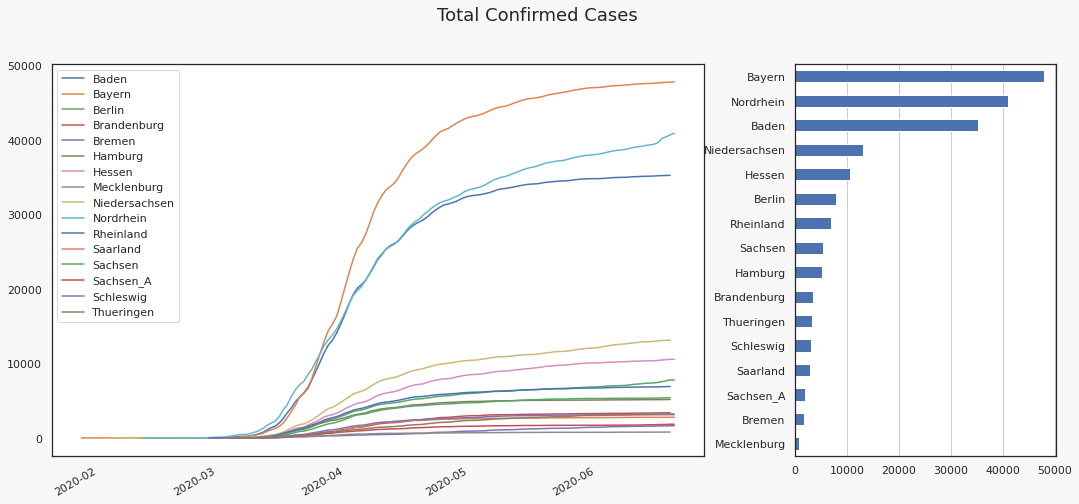

In [34]:
plot_time_count(merged_df,"cumsum_cases", 'Total Confirmed Cases', ['date','state'], legend=True)

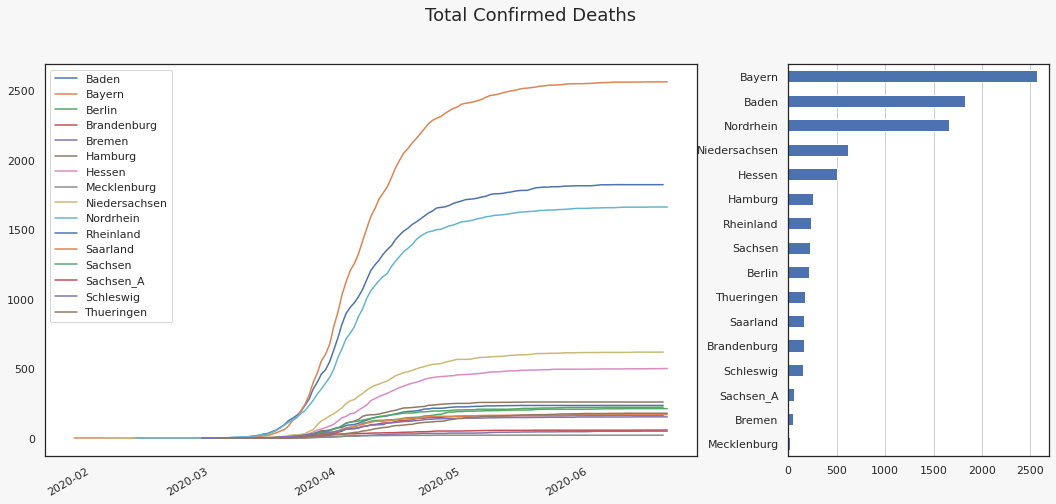

In [35]:
plot_time_count(merged_df,"cumsum_deaths", 'Total Confirmed Deaths', ['date','state'], legend=True)

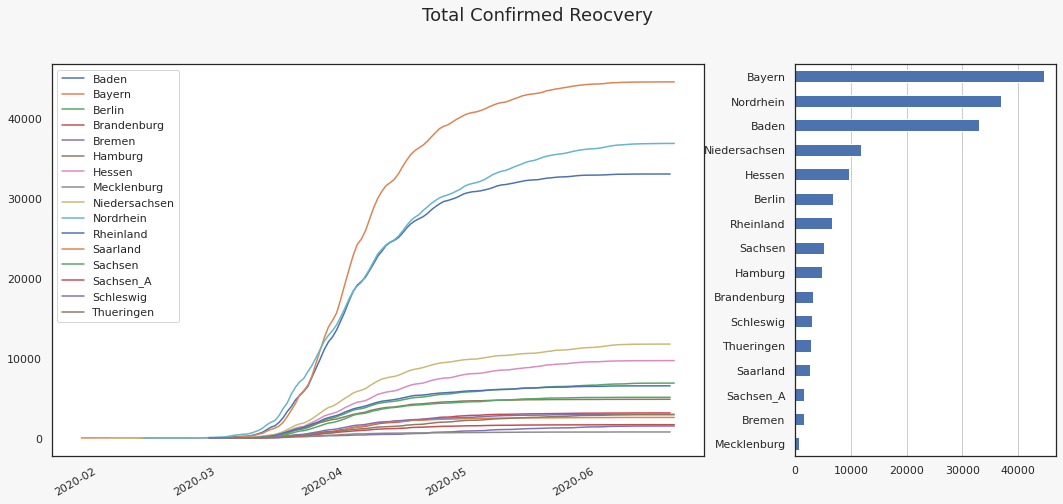

In [36]:
plot_time_count(merged_df,"cumsum_recovered", 'Total Confirmed Reocvery', ['date','state'], legend=True)

In [37]:
plot_stacked('Recovered',["Germany"],"Recovered cases over time")

In [38]:
plot_stacked('Confirmed',["Germany"],"Confirmed cases over time")

In [39]:
plot_stacked('Active',["Germany"],"Active cases over time")

In [40]:
#plot_sup_stacked()

## Cases and deaths per state -MAP


In [41]:
str( shape_de.state[0] )

'Hamburg'

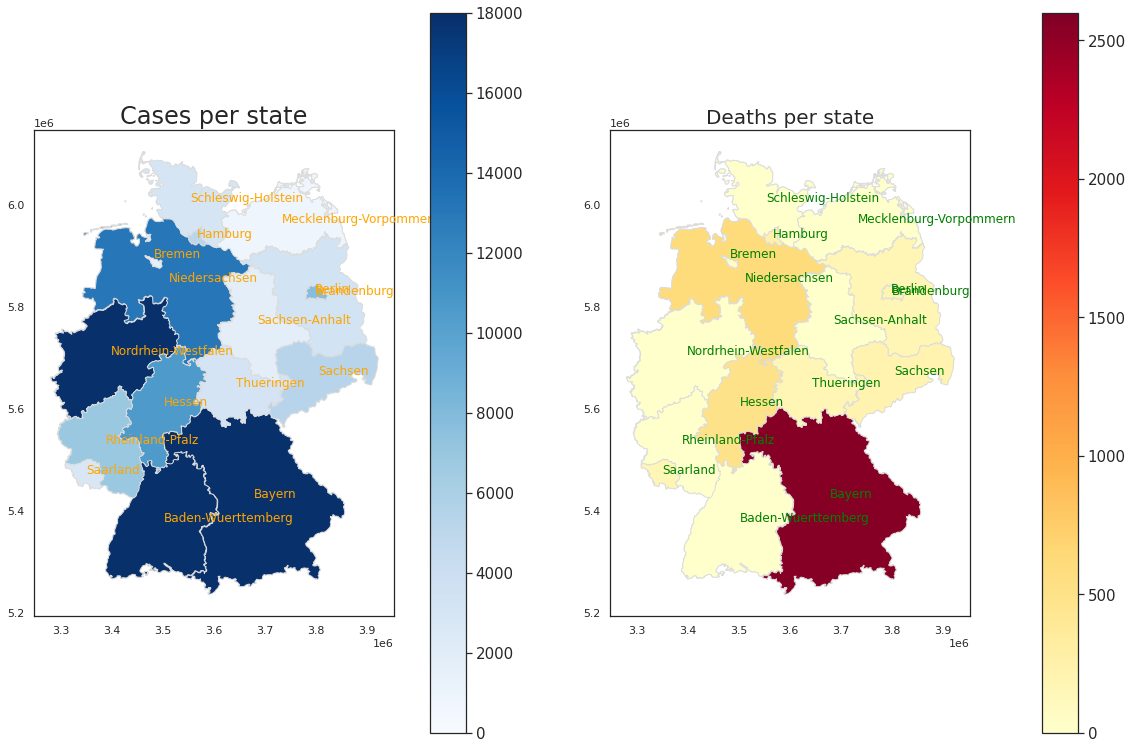

In [42]:
# Set the coordinate reference system (CRS) to EPSG 3035
# Lambert Azimuthal Equal Area -> 3035
shape_de.crs = {'init': 'epsg:3025'}
# print(shape_de.geometry.crs)
plt.figure(figsize=(5,5)) 

# Create a map
ax1 = plt.axes([0., 0., 1., 2.])
shape_de['geometry'].plot(color='whitesmoke', edgecolor='gainsboro', zorder=3, ax = ax1)
for i in shape_de.state:
    add_case_per_state(i)
ax1.set_title('Cases per state', fontsize=24)
for i, geo in shape_de.centroid.iteritems():
    ax1.annotate(s= str( shape_de.state[i]), xy=[geo.x, geo.y], color="orange")


# add colorbar
fig = ax1.get_figure()
cax = fig.add_axes([1.1, 0.0, 0.1, 2.0])
norm = mpl.colors.Normalize(vmin=0,vmax=norm_axis1)
sm = plt.cm.ScalarMappable(norm = norm, cmap='Blues')
sm._A = []
cbar = fig.colorbar(sm, cax=cax , ax=ax1)
cbar.ax.tick_params(labelsize=15)
# Create a second map
ax2 = plt.axes([1.6, 0., 1., 2.])
shape_de['geometry'].plot(figsize=(10,10),color='whitesmoke', edgecolor='gainsboro', zorder=3, ax = ax2)
for i in shape_de.state:
    add_death_per_state(i)
    
# add colorbar
fig2 = ax2.get_figure()
cax2 = fig.add_axes([2.8, 0.0, 0.1, 2.])
norm2 = mpl.colors.Normalize(vmin=0,vmax=norm_axis2)
sm2 = plt.cm.ScalarMappable(norm=norm2,cmap='YlOrRd')
sm2._A = []
cbar = fig.colorbar(sm2, cax=cax2)
cbar.ax.tick_params(labelsize=15)
ax2.set_title('Deaths per state', fontsize=20)
for i, geo in shape_de.centroid.iteritems():
    ax2.annotate(s= str( shape_de.state[i]), xy=[geo.x, geo.y], color="green")


plt.show()

Cases and deaths do mainly occur in highly populated states. In the following, on can check the normalisation per population and population density.

## Tree Map Views of differnt cases in Germany province 

In [43]:
plot_treemap('Confirmed',["US","Brazil","Russia","Germany","France","Spain","Italy","United Kingdom"])

In [44]:
plot_treemap('Deaths',["US","Brazil","Russia","Germany","France","Spain","Italy","United Kingdom"])

In [45]:
plot_treemap('Recovered',["US","Brazil","Russia","Germany","France","Spain","Italy","United Kingdom"])

In [46]:
plot_treemap_germany_state("cumsum_deaths","Cumulative death per Germany state")

In [47]:
plot_treemap_germany_state("cumsum_cases","Cumulative cases per Germany state")

In [48]:
plot_treemap_germany_state("cumsum_recovered","Cumulative recovery per Germany state")

## Growth rate

In [49]:
_tmp_germany = full_grouped[full_grouped["Country/Region"] == "Germany"]
last_day =last_day =_tmp_germany["Date"].values[-1]
datelist = pd.date_range(end = last_day, periods = _tmp_germany["Date"].shape[0]).tolist()
len(datelist)

152

In [50]:
_tmp_germany

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
65,2020-01-22,Germany,0,0,0,0,0,0,0
252,2020-01-23,Germany,0,0,0,0,0,0,0
439,2020-01-24,Germany,0,0,0,0,0,0,0
626,2020-01-25,Germany,0,0,0,0,0,0,0
813,2020-01-26,Germany,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
27554,2020-06-17,Germany,188604,8851,173599,6154,352,31,757
27741,2020-06-18,Germany,189817,8875,173847,7095,1213,24,248
27928,2020-06-19,Germany,190299,8887,173972,7440,482,12,125
28115,2020-06-20,Germany,190670,8895,174609,7166,371,8,637


In [51]:
 _tmp_germany["New deaths"].values[1:]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   2,   0,   1,   0,   4,   2,
         2,   6,   7,   4,  16,  23,  17,  10,  29,  34,  49,  61,  75,
        91, 100, 112, 130, 145, 187, 168, 169, 140, 226, 206, 333, 258,
       160,  31, 286, 172, 100, 510, 248, 300, 107, 127, 276, 171, 246,
       296, 185, 117,  99, 150, 188, 153, 156, 113,  76,  54, 127,   0,
       282, 117, 118,  39,  20,  92,  77, 123,  23,  13,  41,  24,  41,
        78,  63,  59,  25,  33,  22,  26,  63,  56,  42,  34,  26,  10,
        15,   8,  39,  33,  23,  15,  12,  10,  41,  16,  20,  11,  10,
         8,   6,  13,  31,  24,  12,   8,   0])

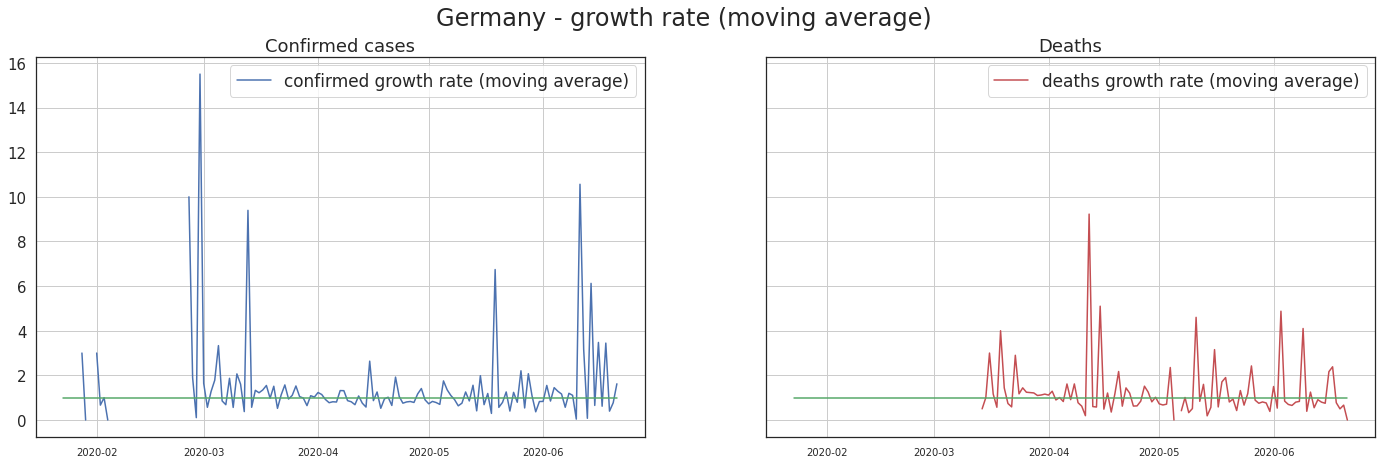

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
fig.suptitle("Germany - growth rate (moving average)", fontsize=24)

axs[0].plot(datelist[1:], _tmp_germany["New cases"].values[1:]/ _tmp_germany["New cases"].values[:-1], label='confirmed growth rate (moving average)', color='b')
axs[0].plot(datelist[1:],[1]* (_tmp_germany["New cases"].shape[0]-1), color='g')
axs[0].legend(fontsize=17)
axs[0].set_title("Confirmed cases", fontsize=18)
axs[0].tick_params(axis='x', labelsize=10)
axs[0].tick_params(axis='y', labelsize=15)
axs[0].grid()

axs[1].plot(datelist[1:], _tmp_germany["New deaths"].values[1:]/_tmp_germany["New deaths"].values[:-1], label='deaths growth rate (moving average)', color='r')
axs[1].plot(datelist[1:], [1]*(_tmp_germany["New deaths"].shape[0]-1), color='g')
axs[1].legend(fontsize=17)
axs[1].set_title("Deaths", fontsize=18)
axs[1].tick_params(axis='x', labelsize=10)
axs[1].tick_params(axis='y', labelsize=15)
axs[1].grid()

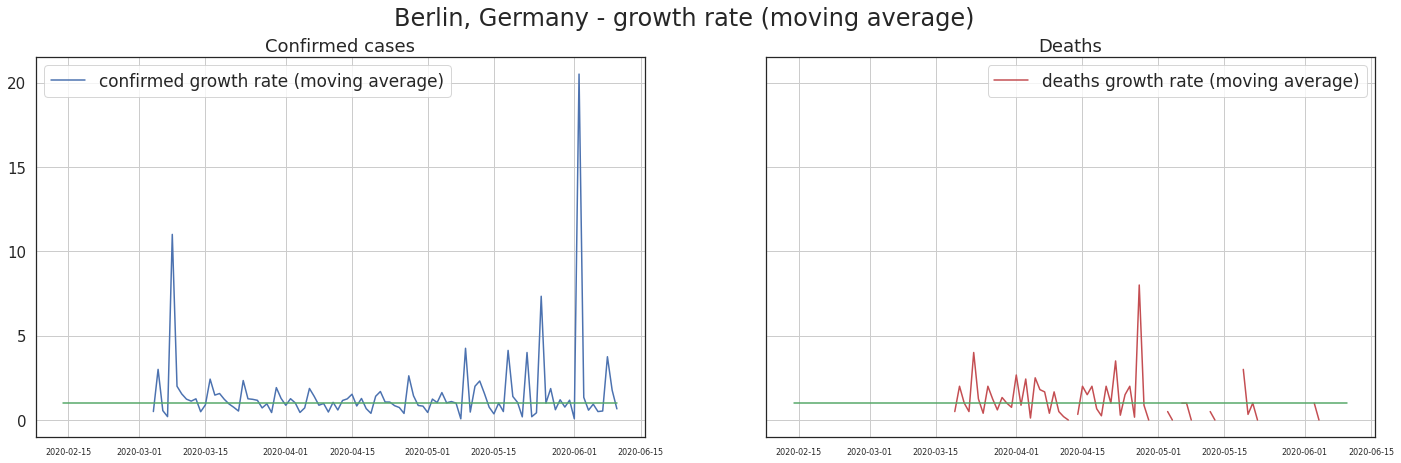

In [54]:
_tmp_state_death = covid_dead_de_state[covid_dead_de_state.index=="Berlin"]
_tmp_state_conf = covid_confirmed_de_state[covid_confirmed_de_state.index=="Berlin"]
last_day =_tmp_state_conf.columns.values[-1]
datelist = pd.date_range(end = last_day, periods = _tmp_state_conf.shape[1]).tolist()
len(datelist)

fig, axs = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
fig.suptitle("Berlin, Germany - growth rate (moving average)", fontsize=24)

axs[0].plot(datelist[1:], _tmp_state_conf.values[0][1:]/_tmp_state_conf.values[0][:-1], label='confirmed growth rate (moving average)', color='b')
axs[0].plot(datelist[1:],[1]* (_tmp_state_conf.shape[1]-1), color='g')
axs[0].legend(fontsize=17)
axs[0].set_title("Confirmed cases", fontsize=18)
axs[0].tick_params(axis='x', labelsize=8)
axs[0].tick_params(axis='y', labelsize=15)
axs[0].grid()

axs[1].plot(datelist[1:], _tmp_state_death.values[0][1:]/_tmp_state_death.values[0][:-1], label='deaths growth rate (moving average)', color='r')
axs[1].plot(datelist[1:],[1]* (_tmp_state_death.shape[1]-1), color='g')
axs[1].legend(fontsize=17)
axs[1].set_title("Deaths", fontsize=18)
axs[1].tick_params(axis='x', labelsize=8)
axs[1].tick_params(axis='y', labelsize=15)
axs[1].grid()

In [ ]:
 covid_dead_de_state[covid_dead_de_state.index=="Nordrhein-Westfalen"]

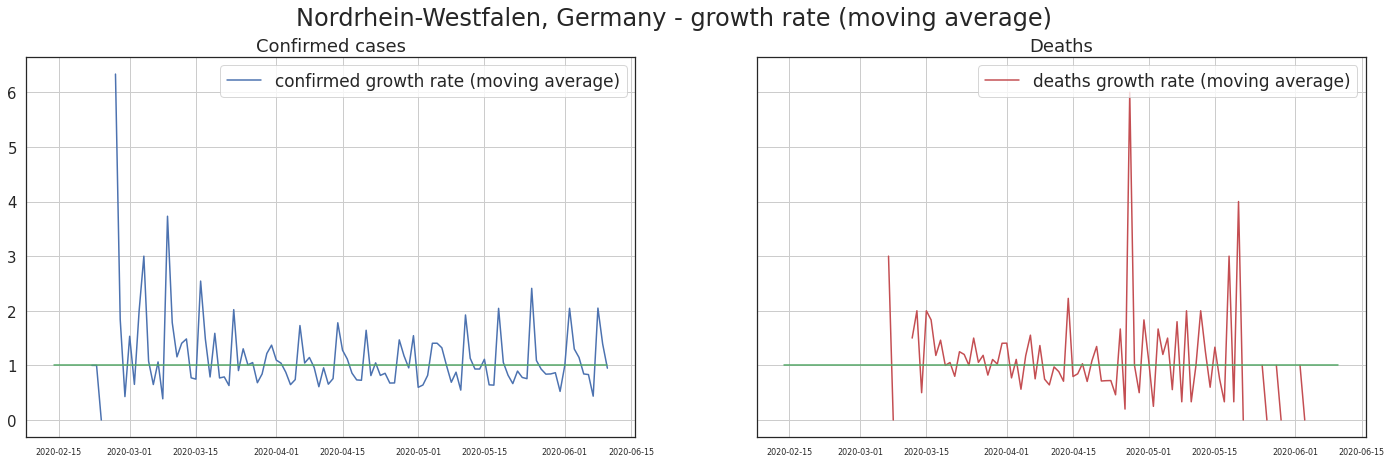

In [55]:

_tmp_state_death = covid_dead_de_state[covid_dead_de_state.index=="Nordrhein-Westfalen"]
_tmp_state_conf = covid_confirmed_de_state[covid_confirmed_de_state.index=="Nordrhein-Westfalen"]
last_day =_tmp_state_conf.columns.values[-1]
datelist = pd.date_range(end = last_day, periods = _tmp_state_conf.shape[1]).tolist()
len(datelist)

fig, axs = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
fig.suptitle("Nordrhein-Westfalen, Germany - growth rate (moving average)", fontsize=24)

axs[0].plot(datelist[1:], _tmp_state_conf.values[0][1:]/_tmp_state_conf.values[0][:-1], label='confirmed growth rate (moving average)', color='b')
axs[0].plot(datelist[1:],[1]* (_tmp_state_conf.shape[1]-1), color='g')
axs[0].legend(fontsize=17)
axs[0].set_title("Confirmed cases", fontsize=18)
axs[0].tick_params(axis='x', labelsize=8)
axs[0].tick_params(axis='y', labelsize=15)
axs[0].grid()

axs[1].plot(datelist[1:], _tmp_state_death.values[0][1:]/_tmp_state_death.values[0][:-1], label='deaths growth rate (moving average)', color='r')
axs[1].plot(datelist[1:],[1]* (_tmp_state_death.shape[1]-1), color='g')
axs[1].legend(fontsize=17)
axs[1].set_title("Deaths", fontsize=18)
axs[1].tick_params(axis='x', labelsize=8)
axs[1].tick_params(axis='y', labelsize=15)
axs[1].grid()

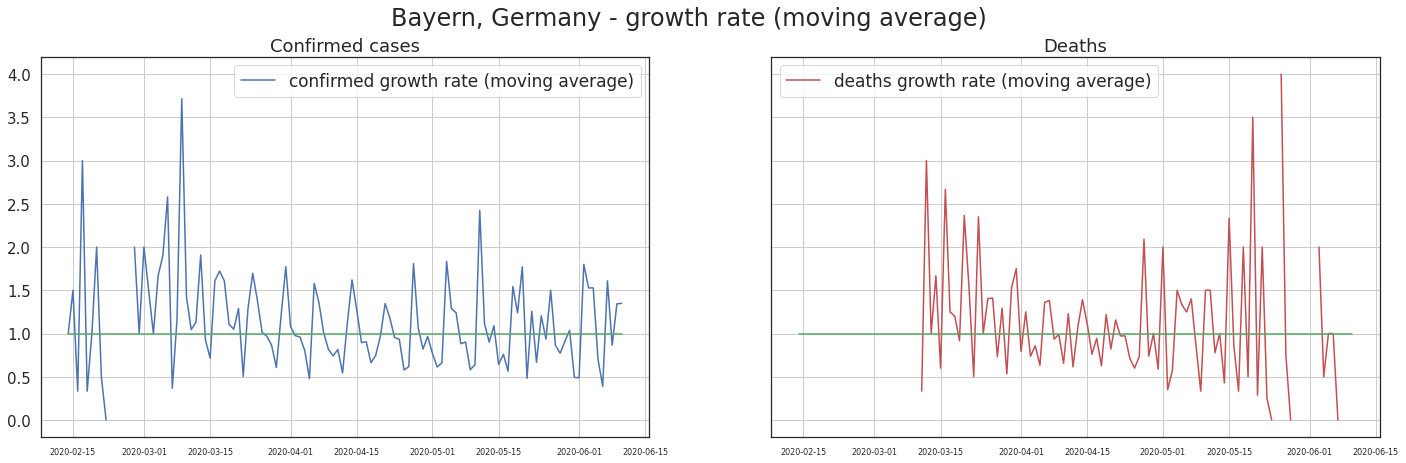

In [56]:
_tmp_state_death = covid_dead_de_state[covid_dead_de_state.index=="Bayern"]
_tmp_state_conf = covid_confirmed_de_state[covid_confirmed_de_state.index=="Bayern"]
last_day =_tmp_state_conf.columns.values[-1]
datelist = pd.date_range(end = last_day, periods = _tmp_state_conf.shape[1]).tolist()
len(datelist)

fig, axs = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
fig.suptitle("Bayern, Germany - growth rate (moving average)", fontsize=24)

axs[0].plot(datelist[1:], _tmp_state_conf.values[0][1:]/_tmp_state_conf.values[0][:-1], label='confirmed growth rate (moving average)', color='b')
axs[0].plot(datelist[1:],[1]* (_tmp_state_conf.shape[1]-1), color='g')
axs[0].legend(fontsize=17)
axs[0].set_title("Confirmed cases", fontsize=18)
axs[0].tick_params(axis='x', labelsize=8)
axs[0].tick_params(axis='y', labelsize=15)
axs[0].grid()

axs[1].plot(datelist[1:], _tmp_state_death.values[0][1:]/_tmp_state_death.values[0][:-1], label='deaths growth rate (moving average)', color='r')
axs[1].plot(datelist[1:],[1]* (_tmp_state_death.shape[1]-1), color='g')
axs[1].legend(fontsize=17)
axs[1].set_title("Deaths", fontsize=18)
axs[1].tick_params(axis='x', labelsize=8)
axs[1].tick_params(axis='y', labelsize=15)
axs[1].grid()

## Clustering

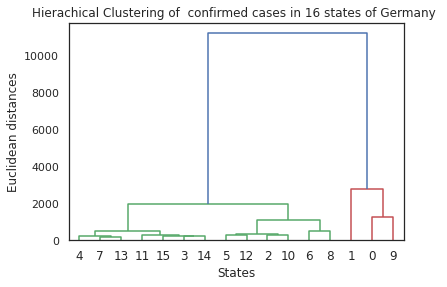

<Figure size 1080x1080 with 0 Axes>

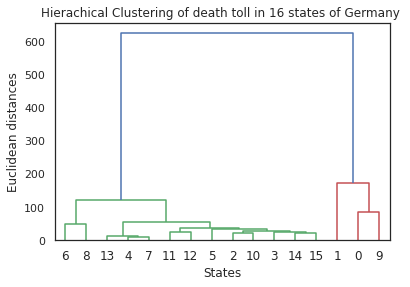

<Figure size 1080x1080 with 0 Axes>

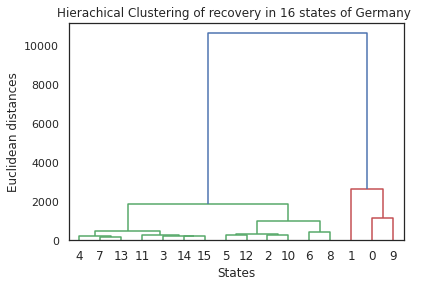

<Figure size 1080x1080 with 0 Axes>

In [57]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(covid_confirmed_de_state, method = 'ward'))
plt.title('Hierachical Clustering of  confirmed cases in 16 states of Germany ')
plt.xlabel('States')
plt.ylabel('Euclidean distances')
plt.figure(figsize=(15,15))
plt.show()

dendrogram = sch.dendrogram(sch.linkage(covid_dead_de_state, method = 'ward'))
plt.title('Hierachical Clustering of death toll in 16 states of Germany ')
plt.xlabel('States')
plt.ylabel('Euclidean distances')
plt.figure(figsize=(15,15))
plt.show()


dendrogram = sch.dendrogram(sch.linkage(covid_recover_de_state, method = 'ward'))
plt.title('Hierachical Clustering of recovery in 16 states of Germany ')
plt.xlabel('States')
plt.ylabel('Euclidean distances')
plt.figure(figsize=(15,15))
plt.show()

* 'Baden-Wuerttemberg' 0
* 'Bayern' 1
* 'Berlin' 2
* 'Brandenburg' 3
* 'Bremen' 4
* 'Hamburg' 5 
* 'Hessen' 6 
* 'Mecklenburg-Vorpommern' 7
* 'Niedersachsen' 8
* 'Nordrhein-Westfalen' 9
* 'Rheinland-Pfalz' 10 
* 'Saarland' 11 
* 'Sachsen' 12
* 'Sachsen-Anhalt' 13 
* 'Schleswig-Holstein' 14 
* 'Thueringen' 15



In [ ]:
covid_confirmed_de_state.index